# **DNA Knot Simulation - Part 6: Knot-type Classification**

*Persistence image + a classifier*

`03_tda_knot_classifier.ipynb` classified chains on the basis of knotted-vs-unknotted (H1 feature count) but it could not distinguish the knot type (no theoretical reason to expect raw feature count to separate say a trefoil from a figure-8). This notebook builds the extension: vectorize full persistence diagrams and train a classifier on them.

This notebook cover:


1.   Setup
2.   Persistence diagram to fixed-length vector
3. Building a labelled, augmented training set
4. Training and evaluating the classifier
5. Generalizing to actual simulated trajectories
6. Limitations



# **A. Setup**

In [ ]:
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/vanikumar03/dna-knots.git"
    REPO_PATH = "/content/dna-knots"
    if not os.path.isdir(REPO_PATH):
        os.system(f"git clone {REPO_URL} {REPO_PATH}")
    os.chdir(f"{REPO_PATH}/notebooks")

sys.path.append(os.path.join(REPO_PATH, 'src') if IN_COLAB else os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import dnasim as ds
import knotclassify as kc

# **B. Persistence diagram to fixed-length vector**

`tdaknot.py`'s `compute_h1_persistence()` only kept lifetimes (birth-death), which is enough for a count but not enough to vectorize the diagram's shape. We keep the raw (birth, death) pairs and input them to `gudhi`'s `PersistenceImage`. This gives a Gaussian-smoothed 2D histogram of the diagram, flattened into a fixed-length vector regardless of how many points the original diagram had (different configurations produce different numbers of H1 features, but a classifier needs fixed-length input).




In [ ]:
def get_h1_diagram(positions_3d):
    """Full (birth, death) H1 persistence diagram. Distance-matrix
    Rips complex as in tdaknot.py, but keeping the raw diagram
    instead of just a count."""
    max_edge = np.ptp(positions_3d, axis=0).max()
    rips = gd.RipsComplex(points=positions_3d, max_edge_length=max_edge)
    st = rips.create_simplex_tree(max_dimension=2)
    persistence = st.persistence()
    diag = np.array([[b, d] for dim, (b, d) in persistence if dim == 1 and d != float('inf')])
    if len(diag) == 0:
        diag = np.zeros((1, 2))  # PersistenceImage needs at least one point
    return diag

In [ ]:
# sanity check: a trefoil's diagram vectorizes to a fixed-length vector
t_param = np.linspace(0, 2*np.pi, 80, endpoint=False)
trefoil_demo = np.stack([np.sin(t_param)+2*np.sin(2*t_param), np.cos(t_param)-2*np.cos(2*t_param), -np.sin(3*t_param)], axis=1)
diag_demo = get_h1_diagram(trefoil_demo)
print(f'Raw diagram: {diag_demo.shape[0]} points')

pi = PersistenceImage(resolution=[15, 15], bandwidth=0.5)
vec_demo = pi.fit_transform([diag_demo])
print(f'Vectorized: fixed-length {vec_demo.shape[1]}-dim vector, regardless of how many points the diagram had')

Raw diagram: 5 points
Vectorized: fixed-length 225-dim vector, regardless of how many points the diagram had


# **C. Building a labelled, augmented training set**

Four knot types: unknot, trefoil, figure-8, cinquefoil

Each base curve is multiplied into many training examples via random 3D rotation + small positional noise






In [ ]:
def torus_knot(p, q, n_points=80, R=2.0):
    t = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    x = (R + np.cos(q*t)) * np.cos(p*t)
    y = (R + np.cos(q*t)) * np.sin(p*t)
    z = np.sin(q*t)
    return np.stack([x, y, z], axis=1)

def figure_eight(n_points=80):
    t = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    x = (2 + np.cos(2*t)) * np.cos(3*t)
    y = (2 + np.cos(2*t)) * np.sin(3*t)
    z = np.sin(4*t)
    return np.stack([x, y, z], axis=1)

def augment(base_curve, seed, noise=0.08):
    # Random 3D rotation + small positional noise (geometric data augmentation for training set size)
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(3, 3))
    Q, R = np.linalg.qr(A)
    Q = Q * np.sign(np.diag(R))
    rotated = base_curve @ Q.T
    rotated += rng.normal(scale=noise, size=rotated.shape)
    return rotated

In [ ]:
base_curves = {
    'unknot':     ds.make_ring(50, bond_length=1.0, seed=0),
    'trefoil':    torus_knot(2, 3, 80),
    'figure-8':   figure_eight(80),
    'cinquefoil': torus_knot(2, 5, 100),
}

N_AUGMENTED_PER_CLASS = 40

X_diagrams, y = [], []
for label, base in base_curves.items():
    for i in range(N_AUGMENTED_PER_CLASS):
        X_diagrams.append(get_h1_diagram(augment(base, seed=i)))
        y.append(label)

print(f'{len(y)} total training examples across {len(base_curves)} knot types '
      f'({N_AUGMENTED_PER_CLASS} augmented copies each)')

160 total training examples across 4 knot types (40 augmented copies each)


# **D. Training and evaluating the classifier**

In [ ]:
pi = PersistenceImage(resolution=[15, 15], bandwidth=0.5)
X_vec = pi.fit_transform(X_diagrams)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.3, random_state=1, stratify=y)

clf = RandomForestClassifier(n_estimators=150, random_state=1)
clf.fit(X_train, y_train)

acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Held-out test accuracy: {acc:.3f}  ({len(y_test)} test examples)')

Held-out test accuracy: 1.000  (48 test examples)


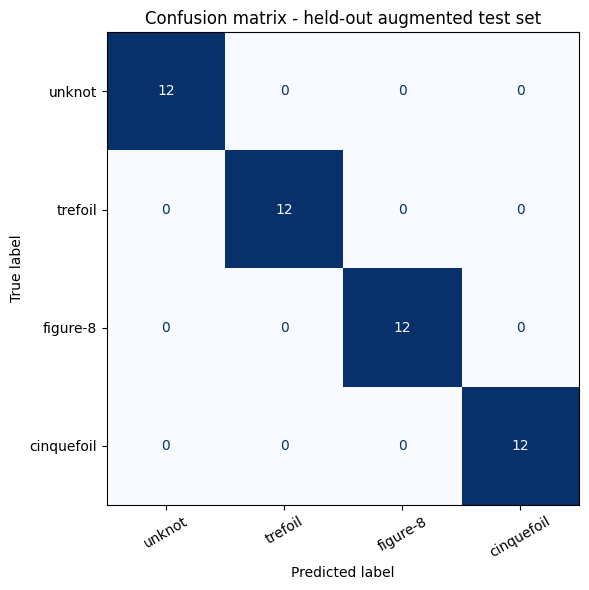

In [ ]:
labels_order = list(base_curves.keys())
cm = confusion_matrix(y_test, clf.predict(X_test), labels=labels_order)
disp = ConfusionMatrixDisplay(cm, display_labels=labels_order)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion matrix - held-out augmented test set')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The test set is drawn from the same geometric augmentation distribution (rotations/noise of the same 4 fixed base curves) as the training set, which makes the high accuracy not surprising. This shows the classifier learned to recognize rotated/perturbed copies of specific curves, not necessarily knot type in a way that generalizes beyond this augmentation scheme. This leads to the next section.






# **E. Generalizing to actual simulated trajectories**

Training data so far was all geometric augmentation and had nothing to do with the actual Langevin dynamics. We now test on simulated, relaxed trajectories for generalization.

In [ ]:
def simulate_and_classify(pos0, n_steps=20000, seed=1, kappa=1.0, true_label=None):
    traj = ds.run_simulation(pos0, n_steps=n_steps, dt=0.0001, gamma=1.0, kT=1.0, seed=seed,
                              record_every=n_steps, K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=kappa)
    final = traj[-1]
    diag = get_h1_diagram(final)
    vec = pi.transform([diag])
    pred = clf.predict(vec)[0]
    proba = clf.predict_proba(vec)[0]
    proba_str = ', '.join(f'{c}:{p:.2f}' for c, p in zip(clf.classes_, proba))
    print(f'true={true_label or "?":<12} predicted={pred:<12} probabilities: {proba_str}')
    return pred

print('Testing on physically simulated (not just rotated) trajectories:\n')

pos0_unknot = ds.make_ring(50, bond_length=1.0, seed=10)
simulate_and_classify(pos0_unknot, seed=11, true_label='unknot')

pos0_tref = ds.make_trefoil_seed(N=60, scale=1.2, seed=0)
simulate_and_classify(pos0_tref, seed=2, true_label='trefoil')

Testing on physically simulated (not just rotated) trajectories:



true=unknot       predicted=unknot       probabilities: cinquefoil:0.02, figure-8:0.01, trefoil:0.14, unknot:0.83


true=trefoil      predicted=cinquefoil   probabilities: cinquefoil:0.64, figure-8:0.07, trefoil:0.29, unknot:0.00


np.str_('cinquefoil')

The unknot generalized correctly with 83% confidence. The classifier predicted cinquefoil with 64% confidence, while the trefoil was correctly labelled only 29% of the times.

The classifier had 100% accuracy against its own held-out test set but failed on different data (real Langevin dynamics output as oppesed to the geometric augmentation the classifier learned from). In practice, the classifier would need to handle data generated by the physical process and not augmentation (has nothing to do with the physics).

40 augmented copies of a single fixed trefoil curve likely aren't diverse enough for the classifier to learn what makes the trefoil's persistence image look the way it does. It may have overfit to the specific geometry of that one curve's diagram rather than learning a property that holds for trefoils in general. A relaxed/thermally-fluctuating trefoil looks different enough from the fixed analytic parameterization that the classifier confused it for a different knot type (but notably adjacent as the classifications were also same-handedness torus knots).

# **F. Limitations**

This notebook demonstrates that the pipeline works but does not provide a validated, generalizing knot-type classifier.

- Training set is small (40 augmented copies $\times$ 4 classes = 160 examples) and drawn from only 4 base curves
- Distinguishing knots that share the same crossing number is not touched upon (all 4 classes tested have different crossing numbers: 0,3,4,5)
- Section E's generalization test is only 2 exampels, and one of them failed. The next step would be to run many simulated trajectories per knot type (training on simulated/thermally-varied configurations directly, rather than on geometric augmentations), with a real sample size: the trefoil misclassification may turn out to be a one-off or systematic.